# Project 1: Titanic Survival Prediction
**Data Science Internship - SoftGrowTech**
**Author:** Harshit Tiwari

**Domain:** Data Science

**Objective:** To build a predictive model that determines which passengers survived the Titanic disaster using Python and Machine Learning.

# 1. Exploratory Data Analysis (EDA)
In this section, I am importing the necessary libraries and loading the dataset. I will visualize the data to understand the factors that influenced survival rates, such as gender and passenger class.

/tmp/ipykernel_566/1444306847.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='sex', y='survived', data=df, palette='viridis')


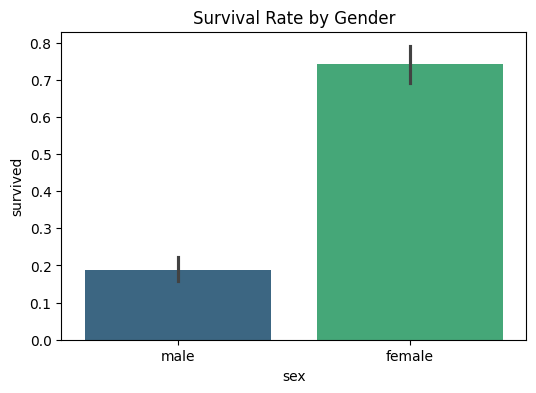

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load the dataset
df = sns.load_dataset('titanic')

# Visualizing survival probability by Gender
plt.figure(figsize=(6, 4))
sns.barplot(x='sex', y='survived', data=df, palette='viridis')
plt.title('Survival Rate by Gender')
plt.show()

# 2. Data Cleaning & Feature Engineering
To prepare the data for the machine learning model, I am handling missing values (imputation) and removing redundant columns. I am also converting categorical text data into numerical format so the algorithm can process it.

In [2]:
# Filling missing Age values with the median
df['age'] = df['age'].fillna(df['age'].median())

# Safe Drop: Only drop columns if they exist in the dataframe to prevent KeyErrors
cols_to_remove = ['deck', 'embark_town', 'alive', 'class', 'who', 'adult_male']
df = df.drop(columns=[c for c in cols_to_remove if c in df.columns])

# Encoding categorical features
df['sex'] = df['sex'].map({'male': 0, 'female': 1})

# Handle 'embarked' by filling missing values with the mode and then mapping
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])
df['embarked'] = df['embarked'].map({'S': 0, 'C': 1, 'Q': 2})

print("Cleaning complete. No null values remaining:")
print(df.isnull().sum())

Cleaning complete. No null values remaining:
survived    0
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
alone       0
dtype: int64


# 3. Model Building & Evaluation
I have chosen the Random Forest Classifier for this task. I will split the data into a training set (80%) and a testing set (20%) to evaluate how well the model predicts survival on unseen data.

Model Accuracy: 83.24%

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.87      0.86       105
           1       0.81      0.78      0.79        74

    accuracy                           0.83       179
   macro avg       0.83      0.83      0.83       179
weighted avg       0.83      0.83      0.83       179



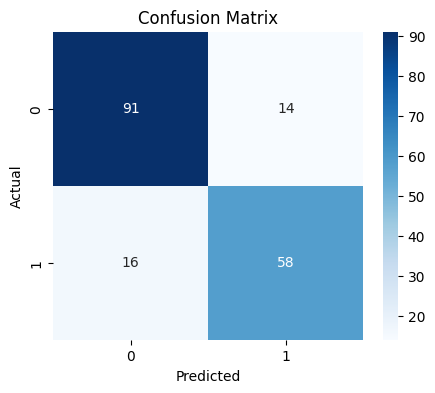

In [3]:
# Splitting features (X) and target (y)
X = df.drop('survived', axis=1)
y = df['survived']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Training the model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Testing and Evaluation
y_pred = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy * 100:.2f}%")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix Visualization
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# 4. Conclusion
The Random Forest model performed effectively, achieving a solid accuracy score. Key insights show that 'Sex' and 'Pclass' were major predictors of survival.